# Unsupervised Learning — Clustering (K-Means & DBSCAN)

Two parts, matching the notes:

**Part A — K-Means + the Elbow Method** on blob-shaped data (`make_blobs`)
**Part B — K-Means vs DBSCAN** on non-circular data (`make_moons`), showing where K-Means breaks down


## 0. Imports & Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
RANDOM_STATE = 42

## Part A — K-Means Clustering + Elbow Method

### A.1 Generate & Scale the Data

`make_blobs` creates well-separated, roughly circular clusters — the case K-Means is built for.
We scale with `StandardScaler` because K-Means relies on distance, and unscaled features
with different ranges would distort it.


In [2]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=4, random_state=RANDOM_STATE)
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
df.head()

,Feature_1,Feature_2
0,-2.282534,-9.692815
1,-6.147668,1.755990
2,13.399091,-1.260023
3,-4.077630,3.160226
4,9.444735,0.340868


### A.2 The Elbow Method — Choosing K

K-Means needs to be told how many clusters (`K`) to look for. We don't know that upfront, so we
fit K-Means for a range of K values and track **WCSS (inertia)** — the total squared distance
from each point to its assigned centroid. WCSS always decreases as K grows; we're looking for the
"elbow" where adding more clusters stops helping much.


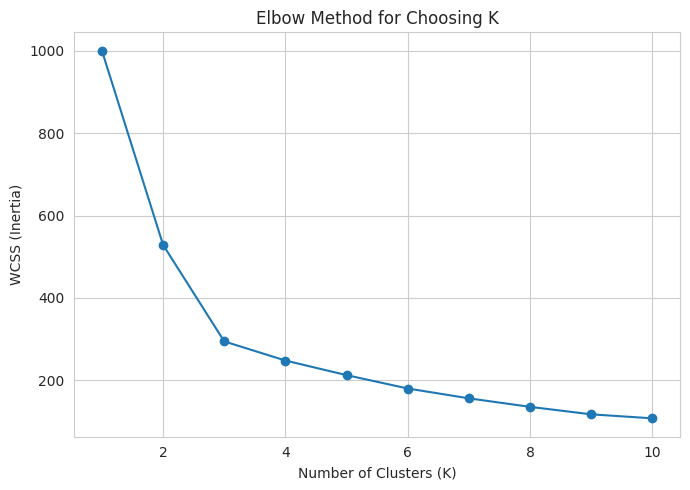

In [3]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)   # WCSS for this K

plt.figure(figsize=(7, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Choosing K')
plt.tight_layout()
plt.show()

### A.3 Fit Final K-Means & Visualize

The elbow above sits at **K = 3** (which matches how we generated the data — 3 centers).


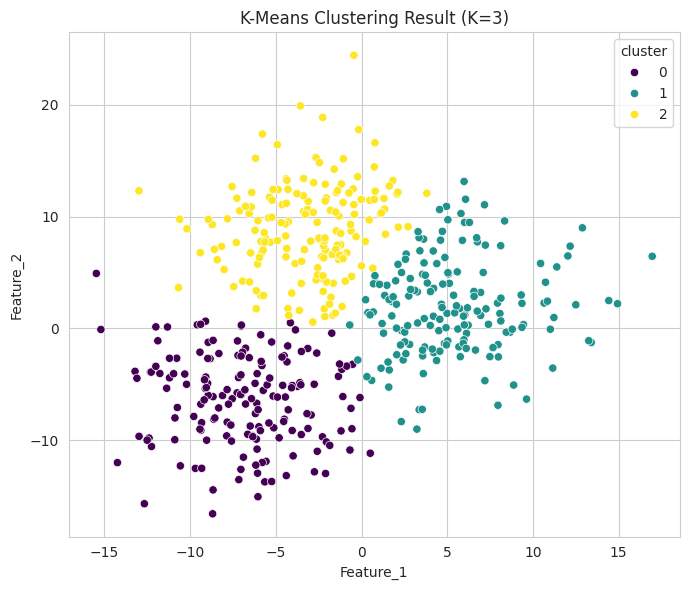

In [4]:
kmeans_final = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['cluster'], palette='viridis')
plt.title('K-Means Clustering Result (K=3)')
plt.tight_layout()
plt.show()

## Part B — K-Means vs DBSCAN on Non-Circular Data

### B.1 Generate Moon-Shaped Data

`make_moons` produces two interleaving crescent shapes — clusters that are **not** circular.
This is the case where K-Means (which assumes roughly spherical clusters) is expected to struggle.


In [5]:
X_m, y_true_m = make_moons(n_samples=500, noise=0.05, random_state=RANDOM_STATE)
df_m = pd.DataFrame(X_m, columns=['Feature_1', 'Feature_2'])

X_m_scaled = StandardScaler().fit_transform(df_m)
df_m.head()

,Feature_1,Feature_2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


### B.2 K-Means on the Moons

In [6]:
kmeans_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
df_m['kmeans_cluster'] = kmeans_moons.fit_predict(X_m_scaled)

### B.3 DBSCAN on the Moons

DBSCAN is **density-based**: it groups points that are closely packed together, and marks
sparse points as noise. It doesn't need K upfront — instead it needs `eps` (neighborhood radius)
and `min_samples` (minimum points to form a dense region).


In [7]:
dbscan_moons = DBSCAN(eps=0.3, min_samples=5)
df_m['dbscan_cluster'] = dbscan_moons.fit_predict(X_m_scaled)

### B.4 Side-by-Side Comparison

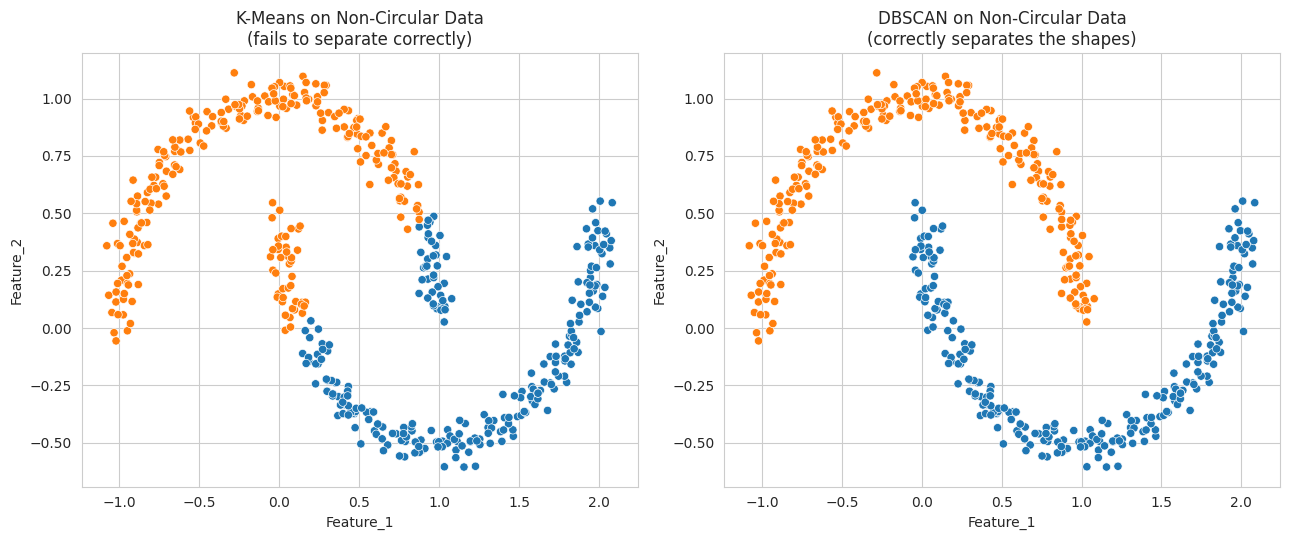

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sns.scatterplot(x=df_m['Feature_1'], y=df_m['Feature_2'],
                 hue=df_m['kmeans_cluster'], palette='tab10', ax=axes[0], legend=False)
axes[0].set_title('K-Means on Non-Circular Data\n(fails to separate correctly)')

sns.scatterplot(x=df_m['Feature_1'], y=df_m['Feature_2'],
                 hue=df_m['dbscan_cluster'], palette='tab10', ax=axes[1], legend=False)
axes[1].set_title('DBSCAN on Non-Circular Data\n(correctly separates the shapes)')

plt.tight_layout()
plt.show()

## Takeaways

- **K-Means**: fast, simple, needs K chosen upfront (use the Elbow Method), assumes roughly
  spherical/circular clusters — struggles on irregular shapes and is sensitive to outliers.
- **DBSCAN**: no need to predefine K, naturally handles noise/outliers, and correctly separates
  arbitrarily-shaped clusters (like the moons above) — but needs `eps`/`min_samples` tuned to
  the data's density.
- Always **scale features** before distance-based clustering — unscaled features distort distances.
